In [ ]:
from google.colab import files
uploaded = files.upload()

Saving df_model.csv to df_model.csv


In [ ]:
!pip install xgboost -q

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

#1. load data
df = pd.read_csv('df_model.csv')
print(df.shape)
df.head(20)

(600, 10)


,city,year,month,precip_in,tavg_f,yr_pop,CO,NO2,O3,PM2.5
0,Chicago,2015,1,1.41,22.4,2757203,0.239951,19.655521,0.016170,13.280614
1,Chicago,2015,2,1.46,14.7,2757203,0.347014,20.637091,0.021669,13.200935
2,Chicago,2015,3,1.10,35.4,2757203,0.259718,19.284992,0.026579,12.673560
3,Chicago,2015,4,2.87,49.4,2757203,0.271056,15.979784,0.030316,9.220072
4,Chicago,2015,5,4.67,60.3,2757203,0.269392,13.292322,0.030410,9.321706
5,Chicago,2015,6,7.12,67.3,2757203,0.243698,13.842576,0.032270,9.546336
6,Chicago,2015,7,2.85,72.3,2757203,0.375038,12.422307,0.033153,14.741716
7,Chicago,2015,8,2.16,71.7,2757203,0.529688,10.659230,0.029487,10.031705
8,Chicago,2015,9,4.64,69.0,2757203,0.192319,12.569572,0.029884,9.920425
9,Chicago,2015,10,2.24,54.7,2757203,0.150814,12.270344,0.021399,7.697172


In [ ]:
try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost is not installed. The code will still run with Linear Regression and Random Forest.")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
print(df.columns.tolist())
for col in df.columns:
    print(repr(col))

['city', 'year', 'month', 'precip_in', 'tavg_f', 'yr_pop', 'CO', 'NO2', 'O3', 'PM2.5']
'city'
'year'
'month'
'precip_in'
'tavg_f'
'yr_pop'
'CO'
'NO2'
'O3'
'PM2.5'


In [ ]:
# -----------------------------
# 2. Basic Cleaning
# -----------------------------
expected_cols = ["city", "year", "month", "precip_in", "tavg_f", "yr_pop", "CO", "NO2", "O3", "PM2.5"]
missing_cols = [c for c in expected_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

df = df.rename(columns={"PM2.5": "PM25"}).copy()

df["city"] = df["city"].astype(str).str.strip()

numeric_cols = ["year", "month", "precip_in", "tavg_f", "yr_pop", "CO", "NO2", "O3", "PM25"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["city", "year", "month", "PM25"]).drop_duplicates().copy()
df["date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))

df = df.sort_values(["city", "date"]).reset_index(drop=True)

print("\nCleaned shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())


Cleaned shape: (596, 11)

Missing values:
city           0
year           0
month          0
precip_in      0
tavg_f         0
yr_pop         0
CO             1
NO2          116
O3             1
PM25           0
date           0
dtype: int64



Average PM2.5 by city:
city
Los Angeles    11.392034
Houston         9.906990
Chicago         9.373695
New York        8.237131
Phoenix         8.146073
Name: PM25, dtype: float64


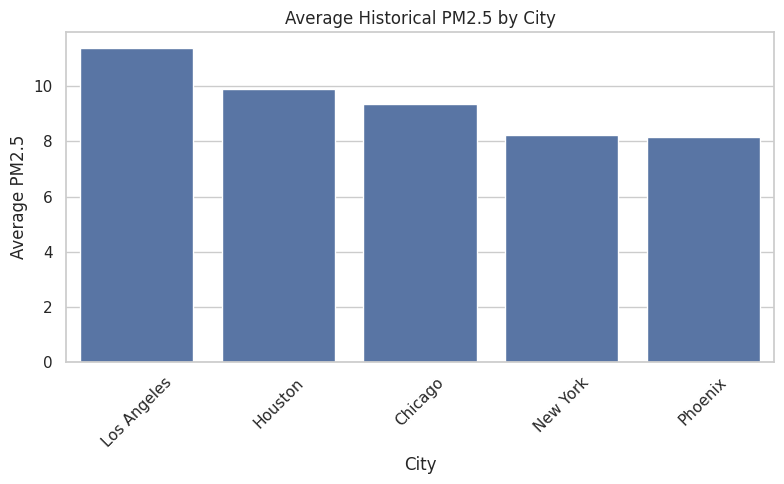

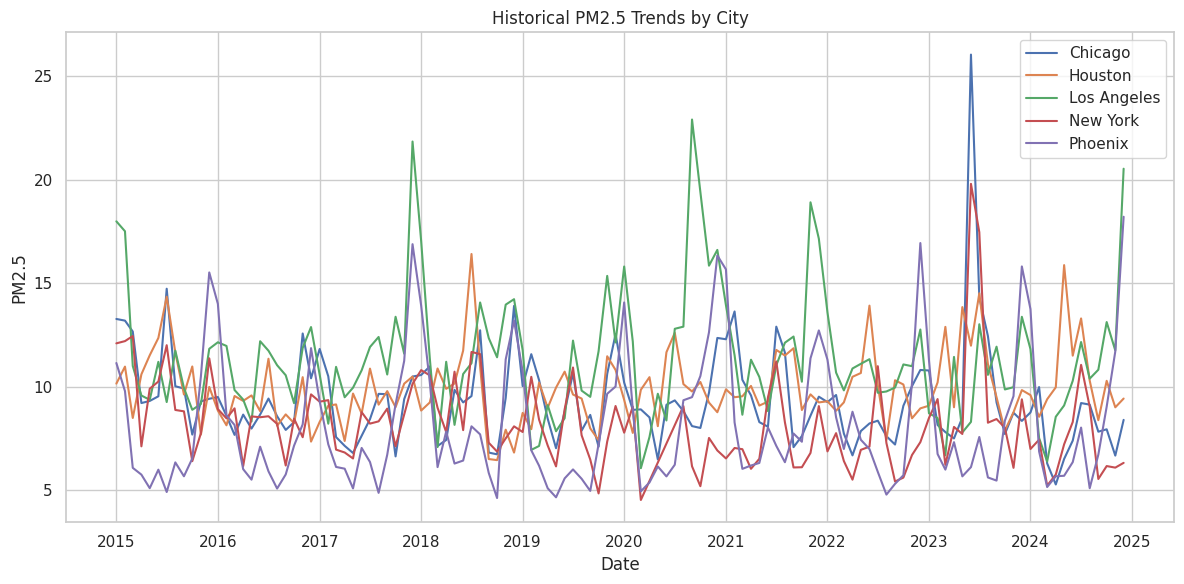

In [ ]:
# ============================================================
# 3. QUICK BI SNAPSHOT
# ============================================================
city_pm25 = df.groupby("city")["PM25"].mean().sort_values(ascending=False)
print("\nAverage PM2.5 by city:")
print(city_pm25)

plt.figure(figsize=(8, 5))
sns.barplot(x=city_pm25.index, y=city_pm25.values)
plt.title("Average Historical PM2.5 by City")
plt.ylabel("Average PM2.5")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for city in df["city"].unique():
    temp = df[df["city"] == city].sort_values("date")
    plt.plot(temp["date"], temp["PM25"], label=city)
plt.title("Historical PM2.5 Trends by City")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Lag features by city
for lag in [1, 3, 12]:
    df[f"PM25_lag_{lag}"] = df.groupby("city")["PM25"].shift(lag)

# Rolling averages using past values only
df["PM25_roll3"] = (
    df.groupby("city")["PM25"]
    .shift(1)
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

df["PM25_roll12"] = (
    df.groupby("city")["PM25"]
    .shift(1)
    .rolling(12)
    .mean()
    .reset_index(level=0, drop=True)
)

# Target = next month's PM2.5
df["target_PM25_next"] = df.groupby("city")["PM25"].shift(-1)

# Keep only rows with lag-based features and target available
model_df = df.dropna(subset=[
    "PM25_lag_1", "PM25_lag_3", "PM25_lag_12",
    "PM25_roll3", "PM25_roll12",
    "target_PM25_next"
]).copy()

# One-hot encode city
model_df = pd.get_dummies(model_df, columns=["city"], drop_first=True)

city_dummy_cols = [c for c in model_df.columns if c.startswith("city_")]

feature_cols = [
    "precip_in", "tavg_f", "yr_pop", "CO", "NO2", "O3",
    "month_sin", "month_cos",
    "PM25_lag_1", "PM25_lag_3", "PM25_lag_12",
    "PM25_roll3", "PM25_roll12"
] + city_dummy_cols

# Final filter: remove any remaining rows with missing feature/target values
modeling_needed_cols = feature_cols + ["target_PM25_next"]

print("Missing values before final modeling filter:")
print(model_df[modeling_needed_cols].isnull().sum())

model_df = model_df.dropna(subset=modeling_needed_cols).copy()

print("\nShape after dropping missing rows for modeling:", model_df.shape)
print("\nMissing values after final filter:")
print(model_df[modeling_needed_cols].isnull().sum())

Missing values before final modeling filter:
precip_in             0
tavg_f                0
yr_pop                0
CO                    1
NO2                 103
O3                    1
month_sin             0
month_cos             0
PM25_lag_1            0
PM25_lag_3            0
PM25_lag_12           0
PM25_roll3            0
PM25_roll12           0
city_Houston          0
city_Los Angeles      0
city_New York         0
city_Phoenix          0
target_PM25_next      0
dtype: int64

Shape after dropping missing rows for modeling: (427, 23)

Missing values after final filter:
precip_in           0
tavg_f              0
yr_pop              0
CO                  0
NO2                 0
O3                  0
month_sin           0
month_cos           0
PM25_lag_1          0
PM25_lag_3          0
PM25_lag_12         0
PM25_roll3          0
PM25_roll12         0
city_Houston        0
city_Los Angeles    0
city_New York       0
city_Phoenix        0
target_PM25_next    0
dtype: int64


In [ ]:
# ============================================================
# 5. TIME-BASED TRAIN / TEST SPLIT
#    Hold out the last 12 unique months as test
# ============================================================
unique_dates = sorted(model_df["date"].unique())
test_dates = unique_dates[-12:]
train_dates = unique_dates[:-12]

train_mask = model_df["date"].isin(train_dates)
test_mask = model_df["date"].isin(test_dates)

X_train = model_df.loc[train_mask, feature_cols].copy()
y_train = model_df.loc[train_mask, "target_PM25_next"].copy()

X_test = model_df.loc[test_mask, feature_cols].copy()
y_test = model_df.loc[test_mask, "target_PM25_next"].copy()

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train end date:", max(train_dates))
print("Test date range:", min(test_dates), "to", max(test_dates))

print("\nCheck final NaNs in X_train:")
print(X_train.isnull().sum().sum())
print("Check final NaNs in X_test:")
print(X_test.isnull().sum().sum())


Train shape: (379, 17)
Test shape: (48, 17)
Train end date: 2023-11-01 00:00:00
Test date range: 2023-12-01 00:00:00 to 2024-11-01 00:00:00

Check final NaNs in X_train:
0
Check final NaNs in X_test:
0



Model Comparison:
               Model       MAE      RMSE        R2
2            XGBoost  1.400576  1.828098  0.667676
1      Random Forest  1.439748  1.906679  0.638492
0  Linear Regression  1.726266  2.343179  0.454024


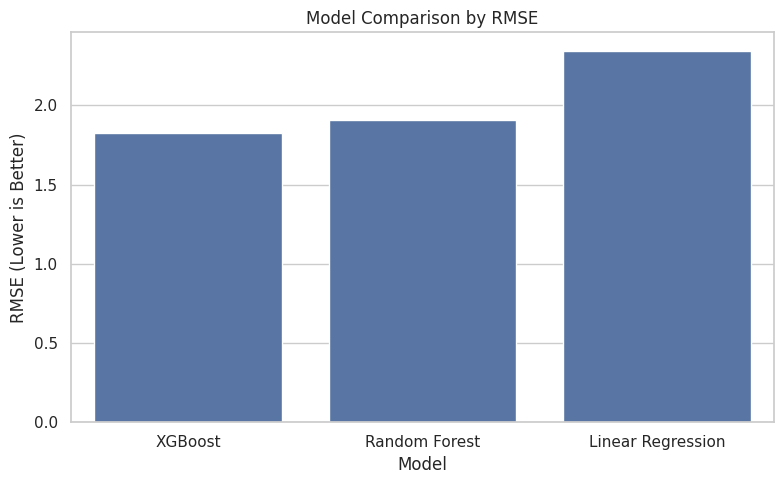


Selected Final Model: XGBoost


In [ ]:
# ============================================================
# 6. MODEL TRAINING + EVALUATION
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost is not installed. The code will still run with Linear Regression and Random Forest.")

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    return {
        "Model": name,
        "ModelObject": model,
        "Predictions": preds,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# Linear Regression baseline
lr = LinearRegression()
results.append(evaluate_model("Linear Regression", lr, X_train, y_train, X_test, y_test))

# Random Forest
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
results.append(evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test))

# XGBoost
if XGB_AVAILABLE:
    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42
    )
    results.append(evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame([{
    "Model": r["Model"],
    "MAE": r["MAE"],
    "RMSE": r["RMSE"],
    "R2": r["R2"]
} for r in results]).sort_values("RMSE")

print("\nModel Comparison:")
print(results_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE (Lower is Better)")
plt.tight_layout()
plt.show()

best_result = sorted(results, key=lambda x: x["RMSE"])[0]
best_model_name = best_result["Model"]
best_model = best_result["ModelObject"]

print(f"\nSelected Final Model: {best_model_name}")


## Selected Final Model: **XGBoost**

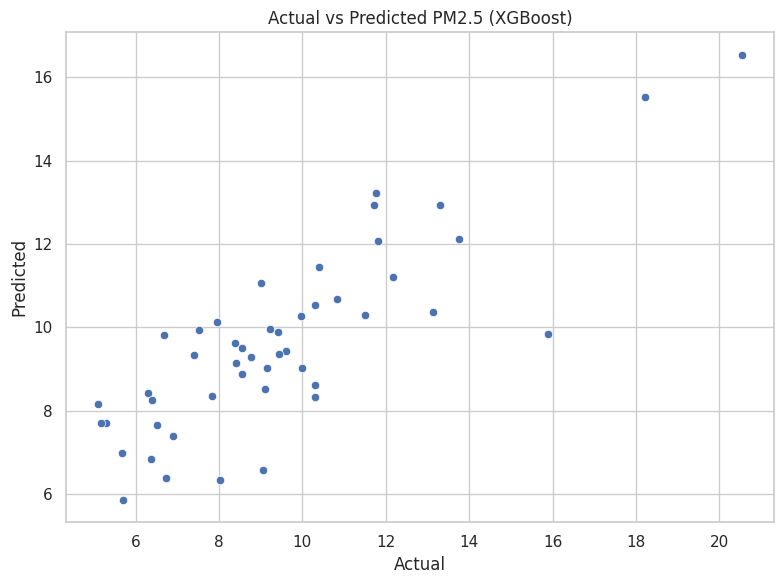

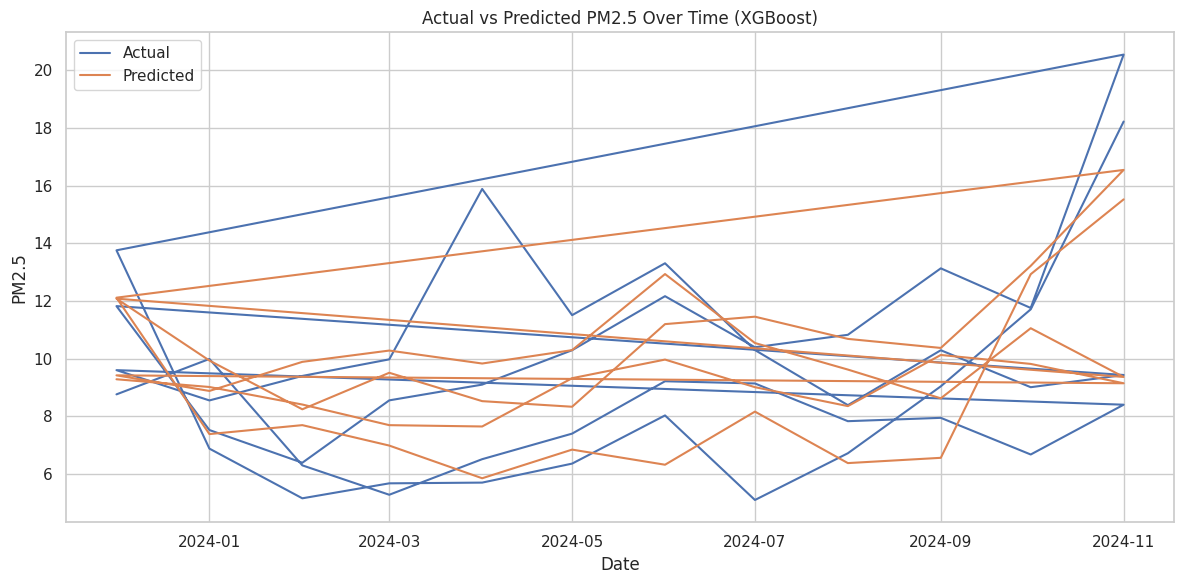

In [ ]:
# ============================================================
# 7. PREDICTION DIAGNOSTICS
# ============================================================
pred_diag = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_result["Predictions"]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pred_diag, x="Actual", y="Predicted")
plt.title(f"Actual vs Predicted PM2.5 ({best_model_name})")
plt.tight_layout()
plt.show()

plot_df = model_df.loc[test_mask, ["date"]].copy()
plot_df["Actual"] = y_test.values
plot_df["Predicted"] = best_result["Predictions"]

plt.figure(figsize=(12, 6))
plt.plot(plot_df["date"], plot_df["Actual"], label="Actual")
plt.plot(plot_df["date"], plot_df["Predicted"], label="Predicted")
plt.title(f"Actual vs Predicted PM2.5 Over Time ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.tight_layout()
plt.show()



Top 15 Features:
         Feature  Importance
6      month_sin    0.157286
10   PM25_lag_12    0.134454
2         yr_pop    0.092760
7      month_cos    0.089417
5             O3    0.071593
16  city_Phoenix    0.061608
13  city_Houston    0.060438
4            NO2    0.059622
3             CO    0.056004
8     PM25_lag_1    0.049063
0      precip_in    0.042278
1         tavg_f    0.035099
11    PM25_roll3    0.033775
12   PM25_roll12    0.033299
9     PM25_lag_3    0.023304


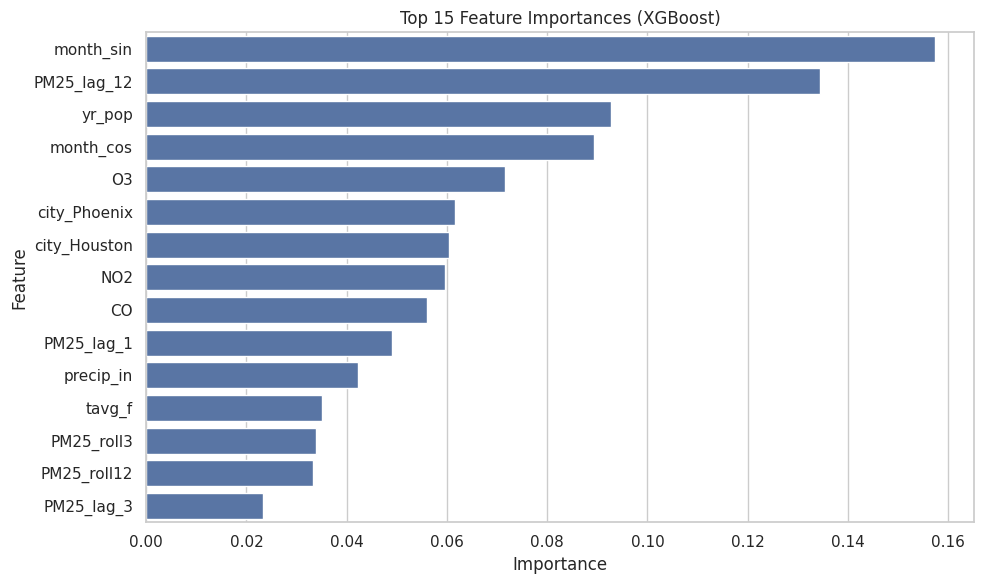

In [ ]:
# ============================================================
# 8. FEATURE IMPORTANCE
# ============================================================
if best_model_name == "Linear Regression":
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": np.abs(best_model.coef_)
    }).sort_values("Importance", ascending=False)
else:
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

print("\nTop 15 Features:")
print(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title(f"Top 15 Feature Importances ({best_model_name})")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 9. BUILD FUTURE EXOGENOUS ASSUMPTIONS FOR 12-MONTH FORECAST
# ============================================================
original_df = df.copy()

# City-month historical averages for exogenous variables
month_avg = (
    original_df.groupby(["city", "month"])[["precip_in", "tavg_f", "CO", "NO2", "O3"]]
    .mean()
    .reset_index()
)

city_avg = (
    original_df.groupby("city")[["precip_in", "tavg_f", "CO", "NO2", "O3"]]
    .mean()
    .reset_index()
)

# City-specific linear population trend
pop_trend = {}
for city in original_df["city"].unique():
    temp = (
        original_df[original_df["city"] == city][["year", "yr_pop"]]
        .drop_duplicates()
        .sort_values("year")
    )
    if len(temp) >= 2:
        slope, intercept = np.polyfit(temp["year"], temp["yr_pop"], 1)
        pop_trend[city] = {"slope": slope, "intercept": intercept}
    else:
        pop_trend[city] = {
            "slope": 0,
            "intercept": temp["yr_pop"].iloc[0] if len(temp) == 1 else 0
        }

def get_future_exogenous(city, month, year):
    row = month_avg[(month_avg["city"] == city) & (month_avg["month"] == month)]
    if len(row) == 0:
        row = city_avg[city_avg["city"] == city]
    row = row.iloc[0]

    pop_est = pop_trend[city]["slope"] * year + pop_trend[city]["intercept"]

    return {
        "precip_in": row["precip_in"],
        "tavg_f": row["tavg_f"],
        "CO": row["CO"],
        "NO2": row["NO2"],
        "O3": row["O3"],
        "yr_pop": pop_est
    }



Future 12-month forecast:
      city forecast_date  forecast_year  forecast_month  predicted_PM25  \
0  Chicago    2025-01-01           2025               1        9.941730   
1  Chicago    2025-02-01           2025               2        8.122499   
2  Chicago    2025-03-01           2025               3        8.141235   
3  Chicago    2025-04-01           2025               4        7.571689   
4  Chicago    2025-05-01           2025               5        8.928261   

   projected_population  
0             2692130.4  
1             2692130.4  
2             2692130.4  
3             2692130.4  
4             2692130.4  


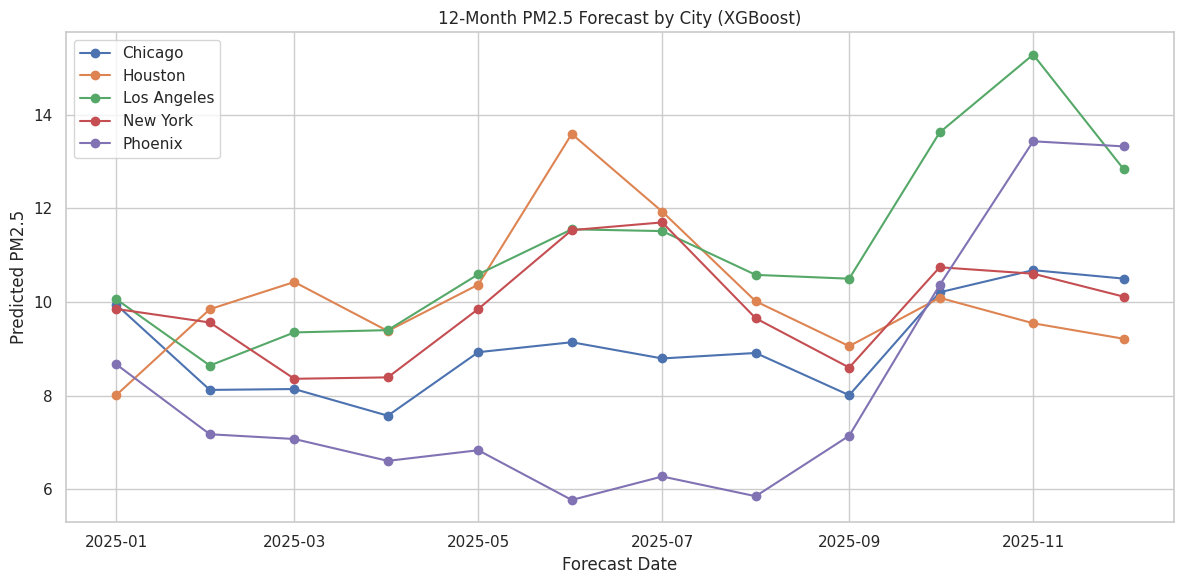

In [ ]:
# ============================================================
# 10. RECURSIVE 12-MONTH FORECAST BY CITY
# ============================================================
all_cities = sorted(original_df["city"].unique())
base_city = all_cities[0]  # omitted city in drop_first encoding

def build_city_dummy_dict(city_name):
    dummy_dict = {col: 0 for col in city_dummy_cols}
    if city_name != base_city:
        col_name = f"city_{city_name}"
        if col_name in dummy_dict:
            dummy_dict[col_name] = 1
    return dummy_dict

future_forecasts = []

for city in all_cities:
    city_hist = original_df[original_df["city"] == city].sort_values("date").copy()

    if len(city_hist) < 12:
        print(f"Skipping {city}: not enough history for 12-month lag features.")
        continue

    pm25_history = list(city_hist["PM25"].values)
    last_date = city_hist["date"].max()

    for step in range(1, 13):
        forecast_date = last_date + pd.DateOffset(months=step)
        forecast_year = forecast_date.year
        forecast_month = forecast_date.month

        exog = get_future_exogenous(city, forecast_month, forecast_year)

        pm25_lag_1 = pm25_history[-1]
        pm25_lag_3 = pm25_history[-3]
        pm25_lag_12 = pm25_history[-12]
        pm25_roll3 = np.mean(pm25_history[-3:])
        pm25_roll12 = np.mean(pm25_history[-12:])

        row = {
            "precip_in": exog["precip_in"],
            "tavg_f": exog["tavg_f"],
            "yr_pop": exog["yr_pop"],
            "CO": exog["CO"],
            "NO2": exog["NO2"],
            "O3": exog["O3"],
            "month_sin": np.sin(2 * np.pi * forecast_month / 12),
            "month_cos": np.cos(2 * np.pi * forecast_month / 12),
            "PM25_lag_1": pm25_lag_1,
            "PM25_lag_3": pm25_lag_3,
            "PM25_lag_12": pm25_lag_12,
            "PM25_roll3": pm25_roll3,
            "PM25_roll12": pm25_roll12
        }

        row.update(build_city_dummy_dict(city))
        row_df = pd.DataFrame([row])[feature_cols]

        pred_pm25 = best_model.predict(row_df)[0]
        pm25_history.append(pred_pm25)

        future_forecasts.append({
            "city": city,
            "forecast_date": forecast_date,
            "forecast_year": forecast_year,
            "forecast_month": forecast_month,
            "predicted_PM25": pred_pm25,
            "projected_population": exog["yr_pop"]
        })

forecast_df = pd.DataFrame(future_forecasts)

print("\nFuture 12-month forecast:")
print(forecast_df.head())

plt.figure(figsize=(12, 6))
for city in forecast_df["city"].unique():
    temp = forecast_df[forecast_df["city"] == city]
    plt.plot(temp["forecast_date"], temp["predicted_PM25"], marker="o", label=city)
plt.title(f"12-Month PM2.5 Forecast by City ({best_model_name})")
plt.xlabel("Forecast Date")
plt.ylabel("Predicted PM2.5")
plt.legend()
plt.tight_layout()
plt.show()



City Launch Priority Ranking:
          city  predicted_avg_PM25_12m  predicted_peak_PM25_12m  \
0  Los Angeles               11.160043                15.282004   
1     New York                9.913249                11.699430   
2      Houston               10.123032                13.588195   
3      Phoenix                8.209871                13.431033   
4      Chicago                9.078986                10.679558   

   months_above_threshold  projected_population  historical_persistence  \
0                       3          3.841903e+06               11.044342   
1                       0          8.361847e+06                7.104343   
2                       1          2.359209e+06               10.473543   
3                       2          1.687550e+06                8.534055   
4                       0          2.692130e+06                7.793469   

   market_opportunity_score  
0                  0.830696  
1                  0.480953  
2                  0.4794

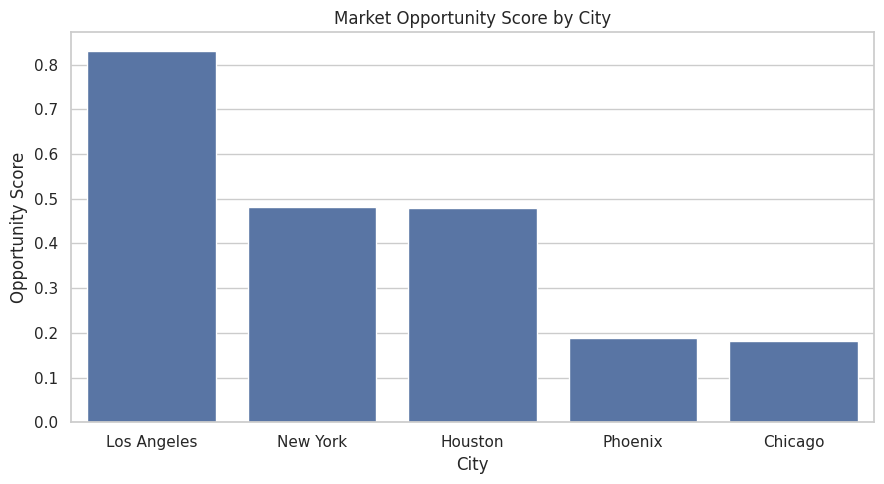

In [ ]:
# ============================================================
# 11. MARKET OPPORTUNITY SCORE
# ============================================================
RISK_THRESHOLD = 12.0

hist_persistence = (
    original_df.sort_values("date")
    .groupby("city")
    .tail(12)
    .groupby("city")["PM25"]
    .mean()
    .reset_index(name="historical_persistence")
)

forecast_summary = (
    forecast_df.groupby("city")
    .agg(
        predicted_avg_PM25_12m=("predicted_PM25", "mean"),
        predicted_peak_PM25_12m=("predicted_PM25", "max"),
        months_above_threshold=("predicted_PM25", lambda x: (x > RISK_THRESHOLD).sum()),
        projected_population=("projected_population", "mean")
    )
    .reset_index()
)

ranking_df = forecast_summary.merge(hist_persistence, on="city", how="left")

def minmax_scale(series):
    if series.max() == series.min():
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / (series.max() - series.min())

ranking_df["score_pollution"] = minmax_scale(ranking_df["predicted_avg_PM25_12m"])
ranking_df["score_population"] = minmax_scale(ranking_df["projected_population"])
ranking_df["score_highrisk"] = minmax_scale(ranking_df["months_above_threshold"])
ranking_df["score_persistence"] = minmax_scale(ranking_df["historical_persistence"])

ranking_df["market_opportunity_score"] = (
    0.40 * ranking_df["score_pollution"] +
    0.25 * ranking_df["score_population"] +
    0.20 * ranking_df["score_highrisk"] +
    0.15 * ranking_df["score_persistence"]
)

ranking_df = ranking_df.sort_values("market_opportunity_score", ascending=False).reset_index(drop=True)

print("\nCity Launch Priority Ranking:")
print(ranking_df[[
    "city",
    "predicted_avg_PM25_12m",
    "predicted_peak_PM25_12m",
    "months_above_threshold",
    "projected_population",
    "historical_persistence",
    "market_opportunity_score"
]])

plt.figure(figsize=(9, 5))
sns.barplot(data=ranking_df, x="city", y="market_opportunity_score")
plt.title("Market Opportunity Score by City")
plt.ylabel("Opportunity Score")
plt.xlabel("City")
plt.tight_layout()
plt.show()


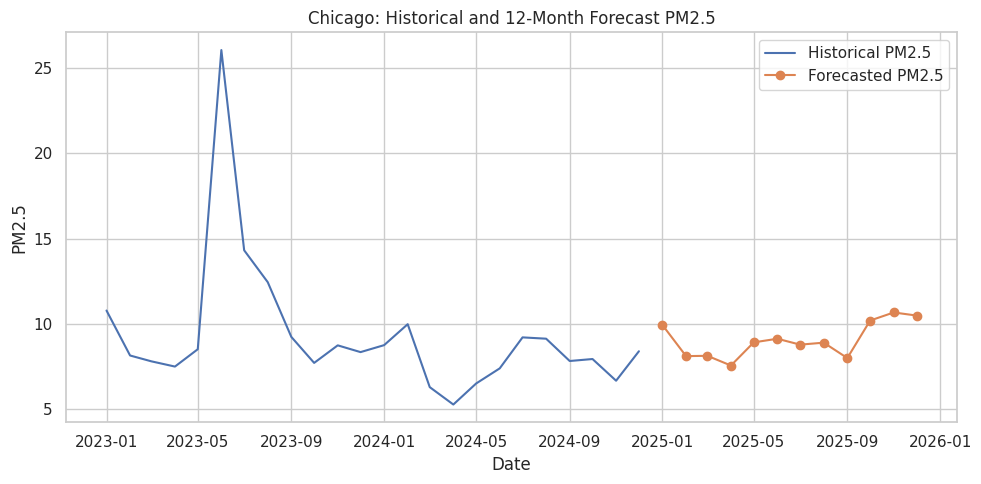

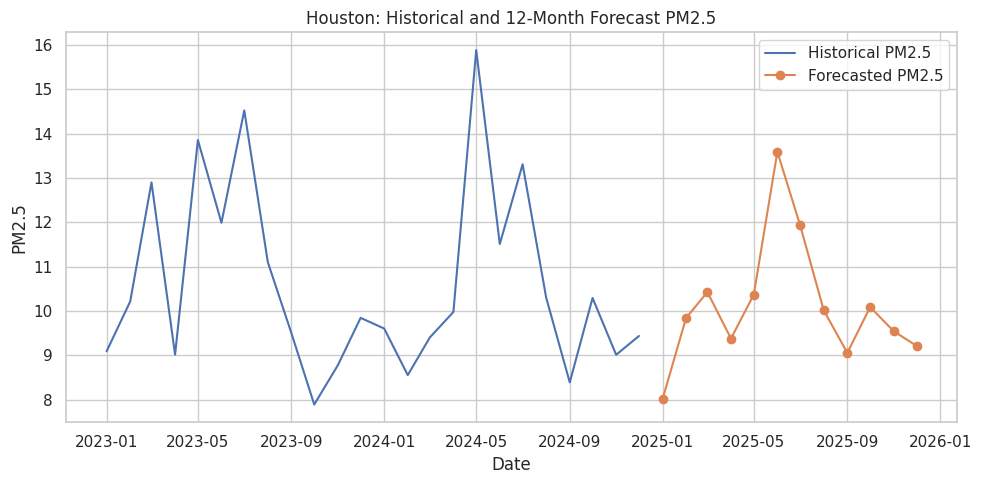

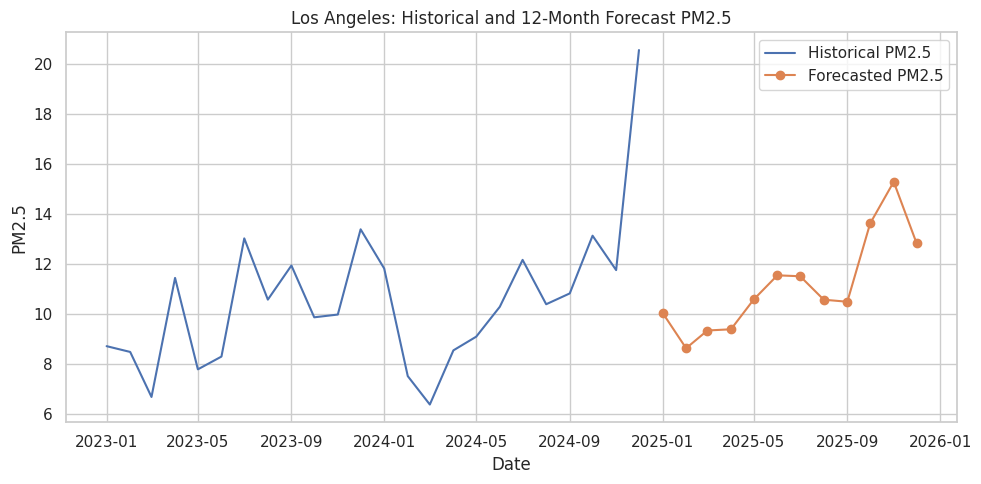

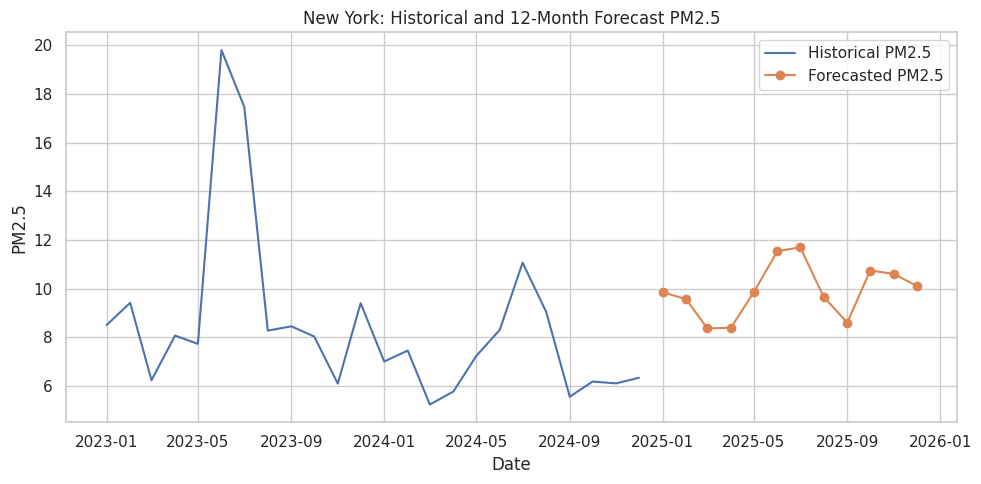

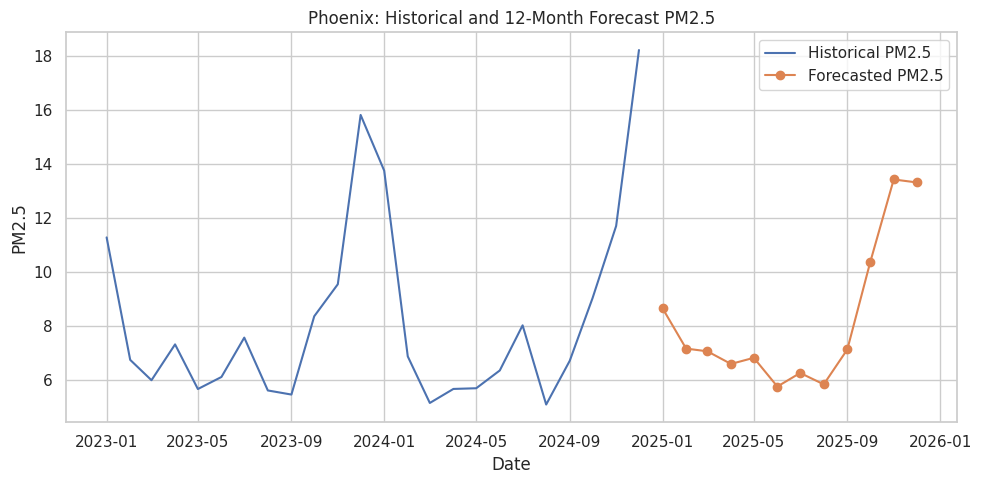

In [ ]:
# ============================================================
# 12. CITY OUTLOOK PLOTS
# ============================================================
for city in all_cities:
    hist_city = original_df[original_df["city"] == city].sort_values("date").tail(24)
    future_city = forecast_df[forecast_df["city"] == city].sort_values("forecast_date")

    plt.figure(figsize=(10, 5))
    plt.plot(hist_city["date"], hist_city["PM25"], label="Historical PM2.5")
    plt.plot(future_city["forecast_date"], future_city["predicted_PM25"], marker="o", label="Forecasted PM2.5")
    plt.title(f"{city}: Historical and 12-Month Forecast PM2.5")
    plt.xlabel("Date")
    plt.ylabel("PM2.5")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================================
# 13. SAVE OUTPUTS
# ============================================================
results_df.to_csv("model_comparison_results.csv", index=False)
importance_df.to_csv("feature_importance_results.csv", index=False)
forecast_df.to_csv("future_12_month_city_forecast.csv", index=False)
ranking_df.to_csv("city_market_opportunity_ranking.csv", index=False)

print("\nSaved files:")
print("- model_comparison_results.csv")
print("- feature_importance_results.csv")
print("- future_12_month_city_forecast.csv")
print("- city_market_opportunity_ranking.csv")


Saved files:
- model_comparison_results.csv
- feature_importance_results.csv
- future_12_month_city_forecast.csv
- city_market_opportunity_ranking.csv


In [ ]:
print("=== results_df ===")
display(results_df)

print("=== ranking_df ===")
display(ranking_df)

print("=== top feature importance ===")
display(importance_df.head(15))

=== results_df ===


,Model,MAE,RMSE,R2
2,XGBoost,1.400576,1.828098,0.667676
1,Random Forest,1.439748,1.906679,0.638492
0,Linear Regression,1.726266,2.343179,0.454024


=== ranking_df ===


,city,predicted_avg_PM25_12m,predicted_peak_PM25_12m,months_above_threshold,projected_population,historical_persistence,score_pollution,score_population,score_highrisk,score_persistence,market_opportunity_score
0,Los Angeles,11.160043,15.282004,3,3.841903e+06,11.044342,1.000000,0.322784,1.000000,1.000000,0.830696
1,New York,9.913249,11.699430,0,8.361847e+06,7.104343,0.577383,1.000000,0.000000,0.000000,0.480953
2,Houston,10.123032,13.588195,1,2.359209e+06,10.473543,0.648491,0.100634,0.333333,0.855127,0.479491
3,Phoenix,8.209871,13.431033,2,1.687550e+06,8.534055,0.000000,0.000000,0.666667,0.362871,0.187764
4,Chicago,9.078986,10.679558,0,2.692130e+06,7.793469,0.294598,0.150515,0.000000,0.174905,0.181704


=== top feature importance ===


,Feature,Importance
6,month_sin,0.157286
10,PM25_lag_12,0.134454
2,yr_pop,0.092760
7,month_cos,0.089417
5,O3,0.071593
16,city_Phoenix,0.061608
13,city_Houston,0.060438
4,NO2,0.059622
3,CO,0.056004
8,PM25_lag_1,0.049063


## **Build an interactive dashboard using Streamlit**

In [ ]:
!pip install streamlit -q
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb > /dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.7 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Air Filtration Market Entry Dashboard", layout="wide")
sns.set_theme(style="whitegrid")

# -----------------------------
# Load outputs from notebook
# -----------------------------
@st.cache_data
def load_data():
    results_df = pd.read_csv("model_comparison_results.csv")
    importance_df = pd.read_csv("feature_importance_results.csv")
    forecast_df = pd.read_csv("future_12_month_city_forecast.csv")
    ranking_df = pd.read_csv("city_market_opportunity_ranking.csv")

    forecast_df["forecast_date"] = pd.to_datetime(forecast_df["forecast_date"])
    return results_df, importance_df, forecast_df, ranking_df

results_df, importance_df, forecast_df, ranking_df = load_data()

# -----------------------------
# Sidebar controls
# -----------------------------
st.sidebar.header("Dashboard Controls")

selected_city = st.sidebar.selectbox(
    "Select a city",
    options=sorted(forecast_df["city"].unique())
)

top_n = st.sidebar.slider(
    "Top N features to display",
    min_value=5,
    max_value=20,
    value=10
)

# -----------------------------
# Header
# -----------------------------
st.title("City Prioritization Dashboard for Air Filtration Market Entry")
st.markdown("""
This dashboard supports a C-suite decision about **which U.S. cities should be prioritized for launching industrial air filtration solutions**.

It combines:
- **historical pollution intelligence**
- **predictive modeling**
- **12-month PM2.5 outlook**
- **market opportunity ranking**
""")

# -----------------------------
# KPI cards
# -----------------------------
best_model = results_df.sort_values("RMSE").iloc[0]
top_city = ranking_df.sort_values("market_opportunity_score", ascending=False).iloc[0]

k1, k2, k3, k4 = st.columns(4)
with k1:
    st.metric("Best Model", best_model["Model"])
with k2:
    st.metric("Best Model RMSE", f"{best_model['RMSE']:.3f}")
with k3:
    st.metric("Top Priority City", top_city["city"])
with k4:
    st.metric("Top Opportunity Score", f"{top_city['market_opportunity_score']:.3f}")

# -----------------------------
# Section 1: Model comparison
# -----------------------------
st.header("1. Model Comparison")

col1, col2 = st.columns(2)

with col1:
    st.dataframe(results_df, use_container_width=True)

with col2:
    fig, ax = plt.subplots()
    sns.barplot(data=results_df, x="Model", y="RMSE", ax=ax)
    ax.set_title("Model Comparison by RMSE")
    ax.set_ylabel("RMSE (Lower is Better)")
    st.pyplot(fig)

st.markdown("""
**Executive interpretation:** We compared Linear Regression, Random Forest, and XGBoost.
The selected final model is the one with the lowest RMSE on the holdout test set.
""")

# -----------------------------
# Section 2: City ranking
# -----------------------------
st.header("2. Market Opportunity Ranking")

st.dataframe(
    ranking_df[[
        "city",
        "predicted_avg_PM25_12m",
        "predicted_peak_PM25_12m",
        "months_above_threshold",
        "projected_population",
        "historical_persistence",
        "market_opportunity_score"
    ]],
    use_container_width=True
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=ranking_df, x="city", y="market_opportunity_score", ax=ax)
ax.set_title("Market Opportunity Score by City")
ax.set_ylabel("Opportunity Score")
st.pyplot(fig)

st.markdown("""
**Executive interpretation:** Higher-ranked cities combine
higher projected pollution burden, larger exposed populations,
more high-risk months, and stronger historical pollution persistence.
""")

# -----------------------------
# Section 3: Selected city forecast
# -----------------------------
st.header("3. 12-Month PM2.5 Outlook by City")

city_forecast = forecast_df[forecast_df["city"] == selected_city].sort_values("forecast_date")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(city_forecast["forecast_date"], city_forecast["predicted_PM25"], marker="o")
ax.set_title(f"{selected_city}: 12-Month Forecasted PM2.5")
ax.set_xlabel("Forecast Date")
ax.set_ylabel("Predicted PM2.5")
st.pyplot(fig)

st.dataframe(city_forecast, use_container_width=True)

# -----------------------------
# Section 4: Feature importance
# -----------------------------
st.header("4. Key Forecast Drivers")

top_features = importance_df.head(top_n).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_features["Feature"], top_features["Importance"])
ax.set_title("Top Forecast Drivers")
ax.set_xlabel("Importance")
st.pyplot(fig)

st.markdown("""
**Executive interpretation:** These variables contribute most to the pollution forecast.
They help leadership understand whether future pollution burden is driven more by
historical PM2.5 persistence, seasonality, temperature, population, or co-pollutants.
""")

# -----------------------------
# Section 5: Recommendations
# -----------------------------
st.header("5. Business Recommendations")

r1, r2, r3 = st.columns(3)

with r1:
    st.markdown("""
    ### 1. Launch Priority
    Prioritize the top-ranked city first, since it combines strong forecasted pollution burden with large population exposure.
    """)

with r2:
    st.markdown("""
    ### 2. Phase 2 Expansion
    Use the next-ranked cities as phase 2 targets, especially those with many forecasted high-risk months.
    """)

with r3:
    st.markdown("""
    ### 3. Review Annually
    Reassess city ranking each year as pollution, weather, and population conditions change.
    """)

# -----------------------------
# Section 6: Strengths & Limitations
# -----------------------------
st.header("6. Strengths and Limitations")

with st.expander("View strengths and limitations"):
    st.markdown("""
    **Strengths**
    - Combines BI and predictive modeling
    - Provides a business-ready city prioritization output
    - Translates technical forecasts into market opportunity ranking

    **Limitations**
    - Forecasts depend on historical patterns and simplified future assumptions
    - Opportunity score uses subjective weights
    - Results support prioritization, not guaranteed market demand
    """)

Writing app.py


In [ ]:
import os
os.system("streamlit run app.py & >/dev/null 2>&1")

0

In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-05-10T20:46:47Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-10T20:46:47Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-10T20:46:50Z INF +--------------------------------------------------------------------------------------------+
2026-05-10T20:46:50Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-10T20:46:50Z INF |  https://proteins-terminal-promotion-description.trycl